# 01 – EDA: profiling, cleaning and the data story (Tasks 1–6)
This notebook loads the Titanic dataset **once** through `sns.load_dataset('titanic')`, saves it to `titanic.csv`
(the offline fallback), then profiles, cleans and explores it. `02_modeling.ipynb` continues from the same `titanic.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
Path("charts").mkdir(exist_ok=True)

## Task 1 – Load and profile

In [2]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

df.info()
print()
print(df.describe())
print()
print("Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

         survived      pclass         age       sibsp       parch        fare
count  891.0000

In [3]:
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Percentage of missing values in EVERY column:\n")
print(missing_pct.to_string())
print("\nColumns that actually have missing values:")
print(missing_pct[missing_pct > 0].to_string())

Percentage of missing values in EVERY column:

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00

Columns that actually have missing values:
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22


## Task 2 – Column-wise missing-value handling (threshold rule)

**Rule:** `< 5 %` missing → drop those rows · `5 % – 30 %` → impute · `> 30 %` → drop the column or encode "Missing" (justified below).

In [4]:
affected = missing_pct[missing_pct > 0]
plan = pd.DataFrame({
    "missing_%": affected,
    "rule_applied": [
        "< 5%  -> drop rows" if p < 5 else ("5-30% -> impute" if p <= 30 else "> 30% -> drop column / 'Missing' category")
        for p in affected
    ],
})
print(plan.to_string())

             missing_%                               rule_applied
deck             77.22  > 30% -> drop column / 'Missing' category
age              19.87                            5-30% -> impute
embarked          0.22                         < 5%  -> drop rows
embark_town       0.22                         < 5%  -> drop rows


In [5]:
clean = df.copy()
clean = clean.dropna(subset=["embarked", "embark_town"])
clean["age"] = clean["age"].fillna(clean["age"].median())
clean = clean.drop(columns=["deck"])

print("Shape before:", df.shape, "-> after:", clean.shape)
print("Remaining missing values:", int(clean.isna().sum().sum()))

Shape before: (891, 15) -> after: (889, 14)
Remaining missing values: 0


**Justification.** Missing rates measured: `deck` 77.22 %, `age` 19.87 %, `embarked` 0.22 %, `embark_town` 0.22 %. `embarked`/`embark_town` are below 5 %, so I dropped those 2 rows (negligible information lost). `age` is in the 5–30 % band, so I imputed it with the median, which is robust to the long right tail of ages. `deck` is above 30 % (77 %), so imputing it would mean inventing most of the values; the imputation would be unreliable, so I dropped the column. (Alternative: encode the gaps as a 'Missing' category, since a missing deck mostly means a 3rd-class cabin.)

## Task 3 – Univariate analysis: `age` and `fare`

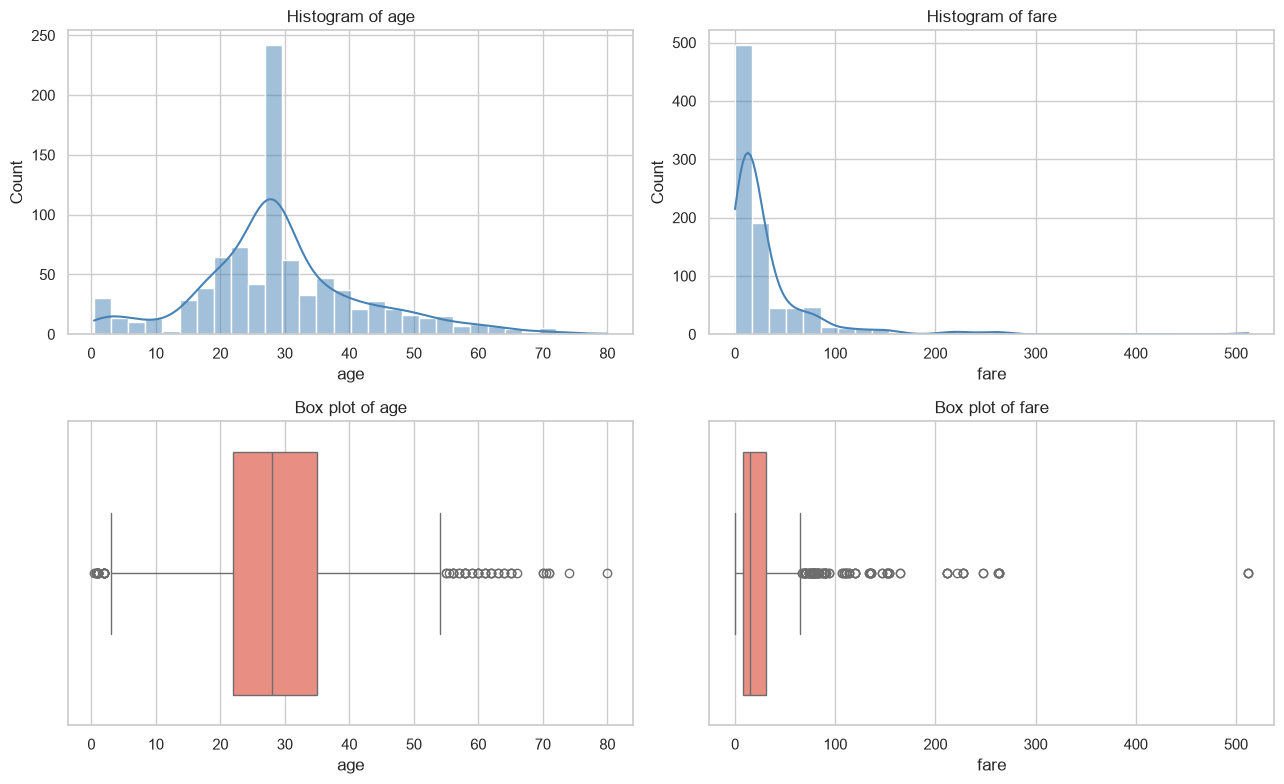

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(clean[col], bins=30, kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Histogram of {col}")
    sns.boxplot(x=clean[col], ax=axes[1, i], color="salmon")
    axes[1, i].set_title(f"Box plot of {col}")
plt.tight_layout()
plt.savefig("charts/01_univariate_age_fare.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), lo, hi

for col in ["age", "fare"]:
    n, lo, hi = iqr_outliers(clean[col])
    print(f"{col:5s}: {n} outliers  (valid range {lo:.2f} to {hi:.2f})")

fare = clean["fare"]
mean_, median_, mode_ = fare.mean(), fare.median(), fare.mode()[0]
print(f"\nfare  mean={mean_:.2f}  median={median_:.2f}  mode={mode_:.2f}  skewness={fare.skew():.2f}")

age  : 65 outliers  (valid range 2.50 to 54.50)
fare : 114 outliers  (valid range -26.76 to 65.66)

fare  mean=32.10  median=14.45  mode=8.05  skewness=4.80


**Interpretation.** `age` has **65** outliers (outside 2.50–54.50) and `fare` has **114** outliers (outside −26.76–65.66, so only the upper end is really flagged because fares cannot be negative). For `fare`, mean = 32.10 > median = 14.45 > mode = 8.05, and the skewness is +4.80, so the distribution is **strongly right-skewed**: most passengers paid small fares while a few paid very large ones (up to £512), pulling the mean far above the median.

## Task 4 – Bivariate analysis

In [8]:
male, female = clean["sex"] == "male", clean["sex"] == "female"
c1, c2, c3 = clean["pclass"] == 1, clean["pclass"] == 2, clean["pclass"] == 3

def rate(mask):
    return round(clean.loc[mask, "survived"].mean() * 100, 2)

print("(a) Survival rate by sex")
print(f"   male   : {rate(male)} %")
print(f"   female : {rate(female)} %")

print("\n(b) Survival rate by pclass")
for name, m in [("1st", c1), ("2nd", c2), ("3rd", c3)]:
    print(f"   {name}: {rate(m)} %")

print("\n(c) Survival rate by sex AND pclass")
rows = []
for s_name, s_mask in [("female", female), ("male", male)]:
    for c_name, c_mask in [("1st", c1), ("2nd", c2), ("3rd", c3)]:
        rows.append({"sex": s_name, "pclass": c_name, "survival_rate_%": rate(s_mask & c_mask),
                     "n": int((s_mask & c_mask).sum())})
print(pd.DataFrame(rows).to_string(index=False))

print("\nExtra example using |  (1st OR 2nd class):", rate(c1 | c2), "%  vs 3rd class:", rate(c3), "%")

(a) Survival rate by sex
   male   : 18.89 %
   female : 74.04 %

(b) Survival rate by pclass
   1st: 62.62 %
   2nd: 47.28 %
   3rd: 24.24 %

(c) Survival rate by sex AND pclass
   sex pclass  survival_rate_%   n
female    1st            96.74  92
female    2nd            92.11  76
female    3rd            50.00 144
  male    1st            36.89 122
  male    2nd            15.74 108
  male    3rd            13.54 347

Extra example using |  (1st OR 2nd class): 55.53 %  vs 3rd class: 24.24 %


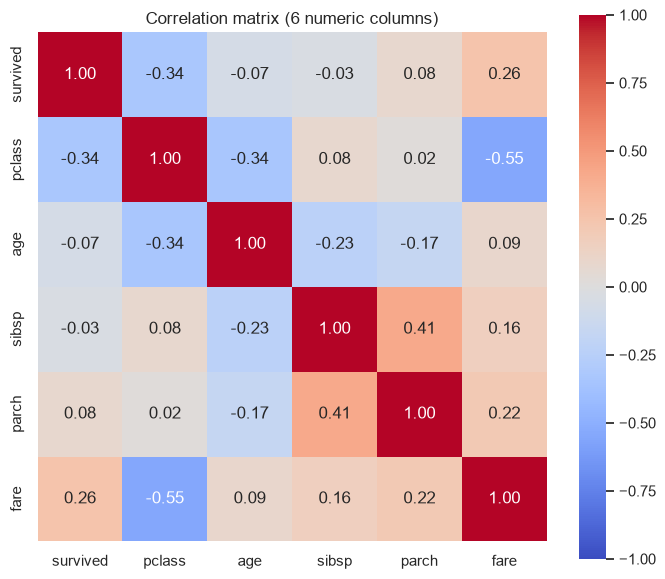

Two strongest correlations (by absolute value):
pclass  fare    -0.548
sibsp   parch    0.415


In [9]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = clean[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout()
plt.savefig("charts/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Two strongest OFF-DIAGONAL pairs by |correlation| (upper triangle only, so each pair counts once)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
top2 = upper.reindex(upper.abs().sort_values(ascending=False).index).head(2)
print("Two strongest correlations (by absolute value):")
print(top2.round(3).to_string())

**Interpretation.** Survival was 74.04 % for women vs 18.89 % for men, and it fell with class (1st 62.62 %, 2nd 47.28 %, 3rd 24.24 %). Women in 1st/2nd class survived at 96.74 % and 92.11 %, whereas men in 3rd class survived at only 13.54 %. The two strongest correlations are **`pclass`–`fare` (r = −0.548)**: higher class number (cheaper class) means lower fare, an intuitive and fairly strong negative link; and **`sibsp`–`parch` (r = +0.415)**: passengers with siblings/spouses also tend to have parents/children aboard, i.e. they travel as families. (For context, the strongest link with `survived` is `pclass` at −0.336.)

## Task 5 – The data story (multivariate charts)

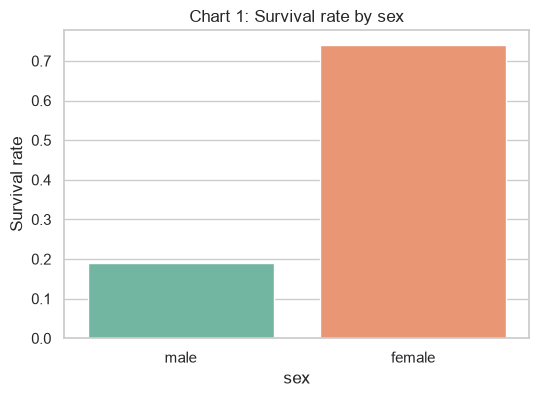

{'female': 0.74, 'male': 0.189}


In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(data=clean, x="sex", y="survived", errorbar=None, palette="Set2", hue="sex", legend=False)
plt.ylabel("Survival rate"); plt.title("Chart 1: Survival rate by sex")
plt.savefig("charts/03_survival_by_sex.png", dpi=150, bbox_inches="tight"); plt.show()
print(clean.groupby("sex")["survived"].mean().round(3).to_dict())

**Interpretation.** Women survived at roughly 74 % versus about 19 % for men, almost four times higher. This is the clearest single pattern in the data and matches the 'women and children first' evacuation policy. Sex alone already separates survivors from victims better than any other single variable.

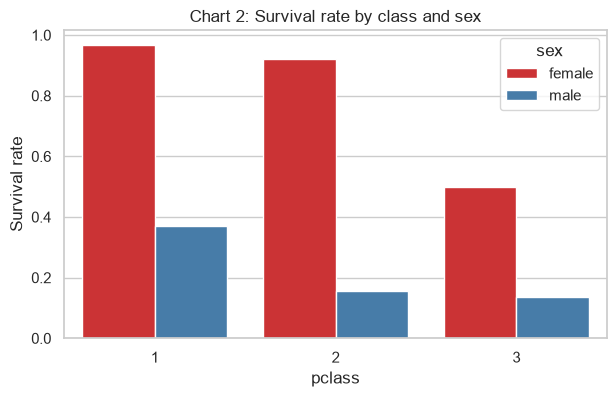

sex     female   male
pclass               
1        0.967  0.369
2        0.921  0.157
3        0.500  0.135


In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=clean, x="pclass", y="survived", hue="sex", errorbar=None, palette="Set1")
plt.ylabel("Survival rate"); plt.title("Chart 2: Survival rate by class and sex")
plt.savefig("charts/04_survival_by_class_sex.png", dpi=150, bbox_inches="tight"); plt.show()
print(clean.groupby(["pclass", "sex"])["survived"].mean().round(3).unstack())

**Interpretation.** Class matters *inside* each sex. Among women, survival drops from 96.7 % (1st) and 92.1 % (2nd) to 50.0 % (3rd); among men it falls from 36.9 % (1st) to about 15.7 % (2nd) and 13.5 % (3rd). So being female protected passengers in every class, but a 3rd-class woman was only about as likely to survive as a coin flip, while a 1st-class man still did better than 2nd/3rd-class men.

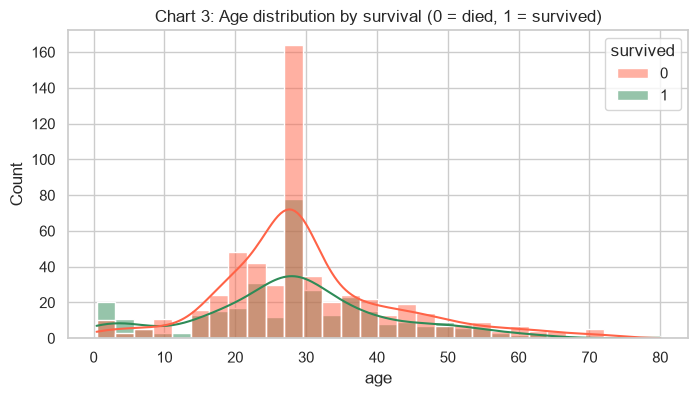

Survival rate age < 12 : 0.574
Survival rate age >= 12: 0.367


In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(data=clean, x="age", hue="survived", bins=30, kde=True, multiple="layer", palette=["tomato", "seagreen"])
plt.title("Chart 3: Age distribution by survival (0 = died, 1 = survived)")
plt.savefig("charts/05_age_by_survival.png", dpi=150, bbox_inches="tight"); plt.show()
print("Survival rate age < 12 :", round(clean.loc[clean.age < 12, "survived"].mean(), 3))
print("Survival rate age >= 12:", round(clean.loc[clean.age >= 12, "survived"].mean(), 3))

**Interpretation.** Children under 12 survived at 57.4 % versus 36.7 % for passengers 12 and older, and the survivor histogram is proportionally taller at the youngest ages. Survival does not differ much across adult ages. The tall spike near 28 is an artefact of imputing about 20 % of missing ages with the median, so age-related conclusions should be read with that in mind.

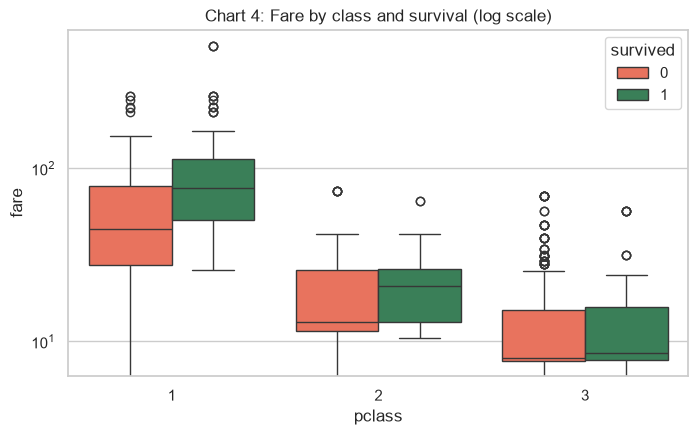

{0: 10.5, 1: 26.0}


In [13]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=clean, x="pclass", y="fare", hue="survived", palette=["tomato", "seagreen"])
plt.yscale("log"); plt.title("Chart 4: Fare by class and survival (log scale)")
plt.savefig("charts/06_fare_by_class_survival.png", dpi=150, bbox_inches="tight"); plt.show()
print(clean.groupby("survived")["fare"].median().round(2).to_dict())

**Interpretation.** Median fare of survivors (26.0) is more than double that of non-survivors (10.5), and within each class survivors tend to sit slightly higher. Most of this difference comes from passenger class (fare and class are strongly linked), so fare is largely a proxy for class/wealth rather than an independent cause. The log scale shows a huge spread in 1st class fares.

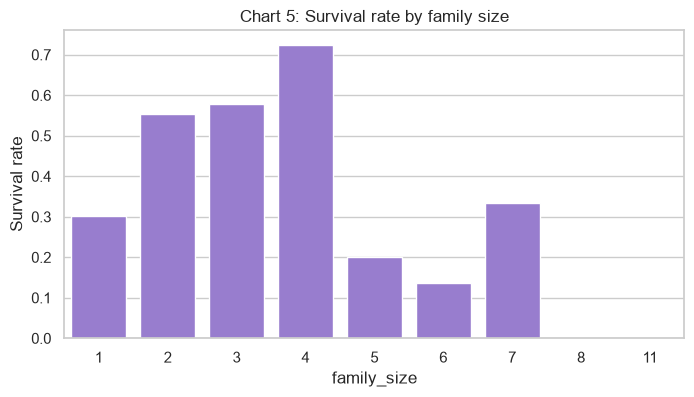

family_size       1        2        3       4     5       6       7    8    11
mean           0.301    0.553    0.578   0.724   0.2   0.136   0.333  0.0  0.0
count        535.000  161.000  102.000  29.000  15.0  22.000  12.000  6.0  7.0


In [14]:
clean["family_size"] = clean["sibsp"] + clean["parch"] + 1
plt.figure(figsize=(8, 4))
sns.barplot(data=clean, x="family_size", y="survived", errorbar=None, color="mediumpurple")
plt.ylabel("Survival rate"); plt.title("Chart 5: Survival rate by family size")
plt.savefig("charts/07_survival_by_family_size.png", dpi=150, bbox_inches="tight"); plt.show()
print(clean.groupby("family_size")["survived"].agg(["mean", "count"]).round(3).T)
clean = clean.drop(columns="family_size") 

**Interpretation.** Solo travellers (family size 1, n = 535) survived at only 30.1 %, small families of 2–4 did best (55 %–72 %), and large families of 5+ did badly (0 %–33 %). Small groups likely helped each other and were often women and children, while very large families were mostly 3rd class and struggled to stay together. Being alone was mostly men, which drags the solo rate down.

**The story in one paragraph.** Who you were on the *Titanic* determined your odds: women survived about four times as often as men (Chart 1), and this held in every class, although 3rd-class women had only a 50 % chance compared with about 97 % in 1st class (Chart 2). Children had a clear advantage over adults (Chart 3), and survivors paid higher fares, but that is mostly because fare reflects class (Chart 4). Finally, travelling in a small family helped, while travelling alone or in a very large group hurt (Chart 5). Together: **being female, young, in a higher class and travelling with a small family gave the best chance of surviving.**

## Task 6 – EDA sanity check: standardise `age` and `fare` (z-score)

      mean_before  std_before  mean_after  std_after
age       29.3152     12.9849         0.0        1.0
fare      32.0967     49.6975         0.0        1.0


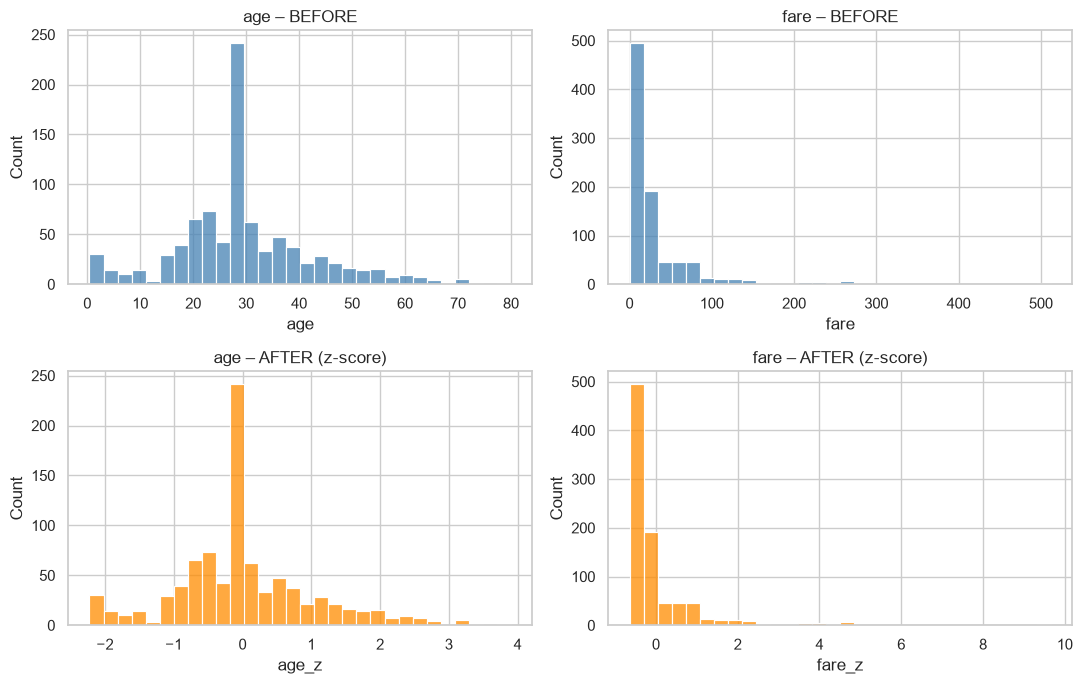

In [15]:
z = pd.DataFrame(index=clean.index)
for col in ["age", "fare"]:
    z[col] = clean[col]
    z[col + "_z"] = (clean[col] - clean[col].mean()) / clean[col].std()   # z = (x - mean) / std

summary = pd.DataFrame({
    "mean_before": z[["age", "fare"]].mean(),
    "std_before":  z[["age", "fare"]].std(),
    "mean_after":  z[["age_z", "fare_z"]].mean().set_axis(["age", "fare"]),
    "std_after":   z[["age_z", "fare_z"]].std().set_axis(["age", "fare"]),
})
print(summary.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(z[col], bins=30, ax=axes[0, i], color="steelblue"); axes[0, i].set_title(f"{col} – BEFORE")
    sns.histplot(z[col + "_z"], bins=30, ax=axes[1, i], color="darkorange"); axes[1, i].set_title(f"{col} – AFTER (z-score)")
plt.tight_layout()
plt.savefig("charts/08_standardisation_before_after.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretation.** Before standardising, `age` had mean 29.32 / std 12.98 and `fare` had mean 32.10 / std 49.70. After the z-score transformation both columns have mean 0.0 and std 1.0, as expected. The histograms have exactly the same shape (fare is still heavily right-skewed); only the scale on the x-axis changed. This is only an EDA sanity check; the modeling notebook re-does scaling with `StandardScaler` fitted on the training split only.